**Question 1 (Full NLP Pipeline)**

In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
nlp = spacy.load("en_core_web_sm")
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
fake_df = pd.read_csv('Fake.csv')
real_df = pd.read_csv('True.csv')

In [ ]:
fake_subset = fake_df.sample(n=200, random_state=42)
real_subset = real_df.sample(n=200, random_state=42)
fake_subset['label'] = 0
real_subset['label'] = 1
df = pd.concat([fake_subset, real_subset], axis=0).reset_index(drop=True)
print(df['label'].value_counts())
print(df.head(400))

label
0    200
1    200
Name: count, dtype: int64
                                                 title  \
0    ABOUT HILLARY’S COUGH: We Discovered The Secre...   
1    BREAKING: OBAMACARE REPEAL Clears First Hurdle...   
2    ‘SLEEPY’ JUSTICE GINSBURG: Excites Crowd By Sa...   
3     WATCH: Kellyanne Conway Very Upset Hillary Cl...   
4     GOP Gives Trump The Middle Finger, Prepares T...   
..                                                 ...   
395  U.N. says fighting stops in Sanaa, Saleh funer...   
396  Brazil's Temer faces new graft charges over JB...   
397  U.S. Senate's Reid, in last round, jabs outsid...   
398  Under China anthem cloud, rare interest in Hon...   
399  Flynn did not initially disclose income from R...   

                                                  text       subject  \
0                                                           politics   
1    The Senate voted 51-48 this afternoon to proce...      politics   
2    So much for the SCOTUS not being

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = text.lower()

    tokens = nltk.word_tokenize(text)

    cleaned_tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]

    return " ".join(cleaned_tokens)

df['cleaned_text'] = df['text'].apply(clean_text)

print(df[['text', 'cleaned_text']].head())

                                                text  \
0                                                      
1  The Senate voted 51-48 this afternoon to proce...   
2  So much for the SCOTUS not being political Che...   
3  White House counselor Kellyanne Conway crawled...   
4  Donald Trump may have decided that Russia is g...   

                                        cleaned_text  
0                                                     
1  senate voted 51-48 afternoon proceed resolutio...  
2  much scotus political check comment equality w...  
3  white house counselor kellyanne conway crawled...  
4  donald trump may decided russia going america ...  


In [ ]:
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def print_morphology_comparison(text, dataset_name, article_num):
    tokens = nltk.word_tokenize(text)

    print(f"\n[Article {article_num}] Comparison: Stemming vs Lemmatization")
    print("=" * 80)
    print(f"DATASET: {dataset_name}")
    print(f"{'Original Word':<20} {'Stemmed (Porter)':<25} {'Lemmatized (WordNet)'}")
    print("-" * 75)

    for word in tokens[:20]:
        stemmed = stemmer.stem(word)
        lemmatized = lemmatizer.lemmatize(word)

        indicator = "*" if stemmed != lemmatized else ""

        print(f"{word:<20} {stemmed:<25} {lemmatized:<25} {indicator}")

column_name = "text"
df = df.dropna(subset=[column_name])

for index, row in df.iterrows():
    print_morphology_comparison(str(row[column_name]), "Fake News Dataset", index + 1)

Streaming output truncated to the last 5000 lines.
transfer             transfer                  transfer                  
its                  it                        it                        
legal                legal                     legal                     
base                 base                      base                      
from                 from                      from                      
Catalonia            catalonia                 Catalonia                 *
to                   to                        to                        
Alicante             alicant                   Alicante                  *

[Article 209] Comparison: Stemming vs Lemmatization
DATASET: Fake News Dataset
Original Word        Stemmed (Porter)          Lemmatized (WordNet)
---------------------------------------------------------------------------
WASHINGTON           washington                WASHINGTON                *
(                    (                         (        

In [ ]:
def get_vocab_size(text_list):
    all_words = " ".join(text_list).split()
    return len(set(all_words))

# 1. Vocab size before (Raw Text)
vocab_before = get_vocab_size(df['text'])

# 2. Vocab size after (Cleaned Text)
vocab_after = get_vocab_size(df['cleaned_text'])

print(f"Vocabulary Size Before: {vocab_before}")
print(f"Vocabulary Size After: {vocab_after}")
print(f"Reduction: {((vocab_before - vocab_after) / vocab_before) * 100:.2f}%")

Vocabulary Size Before: 23944
Vocabulary Size After: 14523
Reduction: 39.35%


In [ ]:
def perform_pos_and_ner(text, article_num):
    print(f"\n{'='*30} ARTICLE {article_num} ANALYSIS {'='*30}")

    # --- 1. POS Tagging ---
    nltk_tokens = nltk.word_tokenize(text)
    nltk_pos = nltk.pos_tag(nltk_tokens)

    spacy_doc = nlp(text)

    print(f"\n[POS TAGGING COMPARISON (First 15 tokens)]")
    print(f"{'Word':<18} {'NLTK (Penn)':<20} {'spaCy (Universal)':<20}")
    print("-" * 60)

    for i in range(min(15, len(nltk_pos), len(spacy_doc))):
        word = nltk_pos[i][0]
        n_tag = nltk_pos[i][1]
        s_tag = spacy_doc[i].pos_
        print(f"{word:<18} {n_tag:<20} {s_tag:<20}")

    # --- 2. Named Entity Recognition (NER) ---
    print(f"\n[NER ANALYSIS (spaCy)]")
    if not spacy_doc.ents:
        print("No entities detected in this snippet.")
    else:
        print(f"{'Entity':<25} {'Label':<20} {'Description'}")
        print("-" * 60)
        for ent in spacy_doc.ents[:10]:
            print(f"{ent.text:<25} {ent.label_:<20} {spacy.explain(ent.label_)}")

for index, row in df.head(5).iterrows():
    perform_pos_and_ner(str(row['text']), index + 1)


============================== ARTICLE 1 ANALYSIS ==============================

[POS TAGGING COMPARISON (First 15 tokens)]
Word               NLTK (Penn)          spaCy (Universal)   
------------------------------------------------------------

[NER ANALYSIS (spaCy)]
No entities detected in this snippet.

============================== ARTICLE 2 ANALYSIS ==============================

[POS TAGGING COMPARISON (First 15 tokens)]
Word               NLTK (Penn)          spaCy (Universal)   
------------------------------------------------------------
The                DT                   DET                 
Senate             NNP                  PROPN               
voted              VBD                  VERB                
51-48              CD                   NUM                 
this               DT                   SYM                 
afternoon          NN                   NUM                 
to                 TO                   DET                 
proceed        

In [ ]:
from collections import Counter
def get_top_entities(dataframe, category_label, limit=3):
    entities = []
    subset = dataframe[dataframe['label'] == category_label]

    for text in subset['text']:
        doc = nlp(str(text))
        entities.extend([ent.text.strip() for ent in doc.ents])

    return Counter(entities).most_common(limit)

top_fake = get_top_entities(df, 0)
top_real = get_top_entities(df, 1)

print("Top 3 Named Entities in FAKE NEWS:")
for ent, count in top_fake:
    print(f"- {ent} ({count} mentions)")

print("\nTop 3 Named Entities in REAL NEWS:")
for ent, count in top_real:
    print(f"- {ent} ({count} mentions)")

Top 3 Named Entities in FAKE NEWS:
- Trump (409 mentions)
- Donald Trump (116 mentions)
- one (108 mentions)

Top 3 Named Entities in REAL NEWS:
- Trump (390 mentions)
- U.S. (326 mentions)
- Reuters (254 mentions)


In [ ]:
from collections import defaultdict

word_pos_map = defaultdict(set)

for text in df['text'].head(50):
    doc = nlp(text)
    for token in doc:
        if token.is_alpha:
            word_pos_map[token.text.lower()].add(token.pos_)

ambiguous_word = None
for word, tags in word_pos_map.items():
    if len(word) > 2 and 'NOUN' in tags and 'VERB' in tags:
        print(f"Detected Lexical Ambiguity: The word '{word}' is used as both {tags}")
        break

Detected Lexical Ambiguity: The word 'care' is used as both {'NOUN', 'PROPN', 'VERB'}


In [ ]:
import nltk
from nltk import CFG

# 1. Define a Context-Free Grammar (CFG)
# The ambiguity here is created by the 'PP' (Prepositional Phrase)
# which can attach to either the Verb Phrase (VP) or the Noun Phrase (NP).
grammar = CFG.fromstring("""
  S -> NP VP
  PP -> P NP
  NP -> Det N | Det N PP | 'i'
  VP -> V NP | V NP PP
  Det -> 'the' | 'a'
  N -> 'man' | 'telescope' | 'dog'
  V -> 'saw' | 'followed'
  P -> 'with'
""")

def detect_syntactic_ambiguity(sentence):
    print(f"Analyzing Sentence: {sentence}\n")

    # 2. Use NLTK ChartParser
    tokens = sentence.lower().split()
    parser = nltk.ChartParser(grammar)

    # 3. Generate all possible parse trees
    trees = list(parser.parse(tokens))

    print(f"--- [TASK 3] Generated {len(trees)} Parse Trees ---\n")

    # 4. Display and Explain Trees
    for i, tree in enumerate(trees, 1):
        print(f"--- TREE {i} ---")
        tree.pretty_print()

        # 4. Explanation of interpretations
        if i == 1:
            print("Interpretation 1: The Prepositional Phrase (with the telescope) modifies the VERB.")
            print("Meaning: The action of 'seeing' was done using the telescope.\n")
        else:
            print("Interpretation 2: The Prepositional Phrase (with the telescope) modifies the NOUN.")
            print("Meaning: The 'man' being seen was carrying or had a telescope.\n")

# --- Execution ---
sent = "I saw the man with the telescope"
detect_syntactic_ambiguity(sent)

Analyzing Sentence: I saw the man with the telescope

--- [TASK 3] Generated 2 Parse Trees ---

--- TREE 1 ---
     S                                    
  ___|___________                          
 |               VP                       
 |    ___________|________                 
 |   |       |            PP              
 |   |       |        ____|___             
 |   |       NP      |        NP          
 |   |    ___|___    |     ___|______      
 NP  V  Det      N   P   Det         N    
 |   |   |       |   |    |          |     
 i  saw the     man with the     telescope

Interpretation 1: The Prepositional Phrase (with the telescope) modifies the VERB.
Meaning: The action of 'seeing' was done using the telescope.

--- TREE 2 ---
     S                                
  ___|_______                          
 |           VP                       
 |    _______|___                      
 |   |           NP                   
 |   |    _______|____                 
 |   |   |  

**Question 2 (TF-IDF + Similarity +
Word Embeddings)**

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Sample Documents
documents = [
    str(df['cleaned_text'][0]),
    str(df['cleaned_text'][1]),
    str(df['cleaned_text'][2])
]

def compute_sklearn_tfidf(docs):
    vectorizer = TfidfVectorizer()

    tfidf_matrix = vectorizer.fit_transform(docs)

    vocabulary = vectorizer.get_feature_names_out()

    idf_values = dict(zip(vocabulary, vectorizer.idf_))

    df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=vocabulary)
    df_tfidf.insert(0, "Document", [f"Doc {i+1}" for i in range(len(docs))])

    return df_tfidf, idf_values, vocabulary


tfidf_table, idf_map, vocab = compute_sklearn_tfidf(documents)


print("\n--- TF-IDF Matrix ---")
print(tfidf_table.to_string(index=False))


--- TF-IDF Matrix ---
Document       27       48       50       51       54      act   action  administration  affordable  afternoon      age   august     back    basis     bill    brady   budget       by     came  capitol     care  chairman  chamber    chaos  charged    check     come  comment  commerce  committee      con  consideration    could     dark     deal     desk  directs   discus  document   donald  drafting  earnest  education   effort   either      end   energy  ensuing  ensuring     enzi  equality  february  filibuster  finance    fully   headed   health      hit    house  immediately      jan     josh  jurisdiction    kevin    labor     laid      law  lawmaker  legislation     like      lol   margin     mean  meaning  measures     meet     mike     much   narrow    obama  obamacare      one     page     part    party   passed    penny  pension  political  preserve   pretty  proceed  process    proof  proposal       re   recess   repeal  repealing  replacement  replacin

In [ ]:
import numpy as np
import pandas as pd

def get_top_tfidf_words(matrix, feature_names, labels, target_label, top_n=15):
    row_indices = np.where(labels == target_label)[0]
    subset_matrix = matrix[row_indices]

    mean_weights = np.asarray(subset_matrix.mean(axis=0)).flatten()

    top_words_df = pd.DataFrame({'word': feature_names, 'score': mean_weights})
    return top_words_df.sort_values(by='score', ascending=False).head(top_n)

feature_names = tfidf_vectorizer.get_feature_names_out()
labels = df['label'].values

top_fake = get_top_tfidf_words(tfidf_matrix, feature_names, labels, 0)
top_real = get_top_tfidf_words(tfidf_matrix, feature_names, labels, 1)

print("TOP 15 IMPORTANT WORDS IN FAKE NEWS:")
print(top_fake[['word', 'score']].to_string(index=False))

print("\nTOP 15 IMPORTANT WORDS IN REAL NEWS:")
print(top_real[['word', 'score']].to_string(index=False))

TOP 15 IMPORTANT WORDS IN FAKE NEWS:
 word    score
  the 0.194137
   to 0.108773
   of 0.086742
  and 0.083564
   in 0.067843
 that 0.066030
trump 0.056385
   is 0.055733
   he 0.043021
   it 0.041388
  for 0.039321
  his 0.036061
  you 0.035396
   on 0.034097
  was 0.033492

TOP 15 IMPORTANT WORDS IN REAL NEWS:
   word    score
    the 0.199483
     to 0.111188
     of 0.091867
    and 0.079552
     in 0.077395
   said 0.060988
     on 0.056943
  trump 0.045730
   that 0.042212
    for 0.039747
     he 0.034519
reuters 0.029976
   with 0.028877
     as 0.028070
    his 0.027147


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import re

# 1. Identify indices for the comparison
fake_indices = df[df['label'] == 0].index.tolist()
real_indices = df[df['label'] == 1].index.tolist()

# Pair A: Two Fake articles
idx_f1, idx_f2 = fake_indices[0], fake_indices[1]
# Pair B: One Fake and one Real article
idx_f, idx_r = fake_indices[0], real_indices[0]

# 2. Function for Jaccard Similarity
def get_jaccard_sim(text1, text2):
    # Tokenize into sets of unique words (lowercase)
    set1 = set(re.findall(r'\w+', text1.lower()))
    set2 = set(re.findall(r'\w+', text2.lower()))
    intersection = set1.intersection(set2)
    union = set1.union(set2)
    return len(intersection) / len(union) if len(union) > 0 else 0

# 3. Compute Cosine Similarity (using your existing tfidf_matrix)
cos_fake_fake = cosine_similarity(tfidf_matrix[idx_f1], tfidf_matrix[idx_f2])[0][0]
cos_fake_real = cosine_similarity(tfidf_matrix[idx_f], tfidf_matrix[idx_r])[0][0]

# 4. Compute Jaccard Similarity
jac_fake_fake = get_jaccard_sim(df.iloc[idx_f1]['text'], df.iloc[idx_f2]['text'])
jac_fake_real = get_jaccard_sim(df.iloc[idx_f]['text'], df.iloc[idx_r]['text'])

# Display Results
print("SIMILARITY ANALYSIS")
print("=" * 40)
print(f"Comparison: FAKE vs FAKE (Articles {idx_f1} & {idx_f2})")
print(f" - Cosine Similarity: {cos_fake_fake:.4f}")
print(f" - Jaccard Similarity: {jac_fake_fake:.4f}")
print("-" * 40)
print(f"Comparison: FAKE vs REAL (Articles {idx_f} & {idx_r})")
print(f" - Cosine Similarity: {cos_fake_real:.4f}")
print(f" - Jaccard Similarity: {jac_fake_real:.4f}")

# Check row 0 specifically
print(f"Row 0 Type: {type(df['text'].iloc[0])}")
print(f"Row 0 Content: '{df['text'].iloc[0]}'")

# If you see [] or NaN, that is the problem.
# Run this to fix it:
df['text'] = df['text'].fillna("").astype(str)

SIMILARITY ANALYSIS
Comparison: FAKE vs FAKE (Articles 0 & 1)
 - Cosine Similarity: 0.0000
 - Jaccard Similarity: 0.0000
----------------------------------------
Comparison: FAKE vs REAL (Articles 0 & 200)
 - Cosine Similarity: 0.0000
 - Jaccard Similarity: 0.0000
Row 0 Type: <class 'str'>
Row 0 Content: ' '


In [ ]:
!pip install gensim
import gensim.downloader as api

# 1. Load the pre-trained Google News model (limiting to top 100k words for speed)
# If this is your first time, it will download the model automatically.
wv = api.load('word2vec-google-news-300')

# 2. Compute Similarities
sim_fake_false = wv.similarity('fake', 'false')
sim_fake_official = wv.similarity('fake', 'official')

print(f"Similarity ('fake', 'false'): {sim_fake_false:.4f}")
print(f"Similarity ('fake', 'official'): {sim_fake_official:.4f}")

# 3. Top 5 similar words for 'government'
print("\nTop 5 words similar to 'government':")
for word, score in wv.most_similar('government', topn=5):
    print(f"{word}: {score:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 13.1 MB/s eta 0:00:00
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Similarity ('fake', 'false'): 0.5557
Similarity ('fake', 'official'): 0.2033

Top 5 words similar to 'government':
Government: 0.7132
goverment: 0.7049
governent: 0.6665
governments: 0.6522
govern_ment: 0.6326


Question 3 (Advanced Classification)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

# 1. Split the data (using tfidf_matrix from previous steps)
X_train, X_test, y_train, y_test = train_test_split(tfidf_matrix, df['label'], test_size=0.2, random_state=42)

# 2. Initialize and Train
nb_model = MultinomialNB()
lr_model = LogisticRegression()

nb_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

# 3. Predict and Evaluate
models = {"Naïve Bayes": nb_model, "Logistic Regression": lr_model}

for name, model in models.items():
    preds = model.predict(X_test)
    print(f"\n--- {name} Performance ---")
    print(classification_report(y_test, preds))
    print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")


--- Naïve Bayes Performance ---
              precision    recall  f1-score   support

           0       1.00      0.77      0.87        44
           1       0.78      1.00      0.88        36

    accuracy                           0.88        80
   macro avg       0.89      0.89      0.87        80
weighted avg       0.90      0.88      0.87        80

Accuracy: 0.8750

--- Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       1.00      0.80      0.89        44
           1       0.80      1.00      0.89        36

    accuracy                           0.89        80
   macro avg       0.90      0.90      0.89        80
weighted avg       0.91      0.89      0.89        80

Accuracy: 0.8875


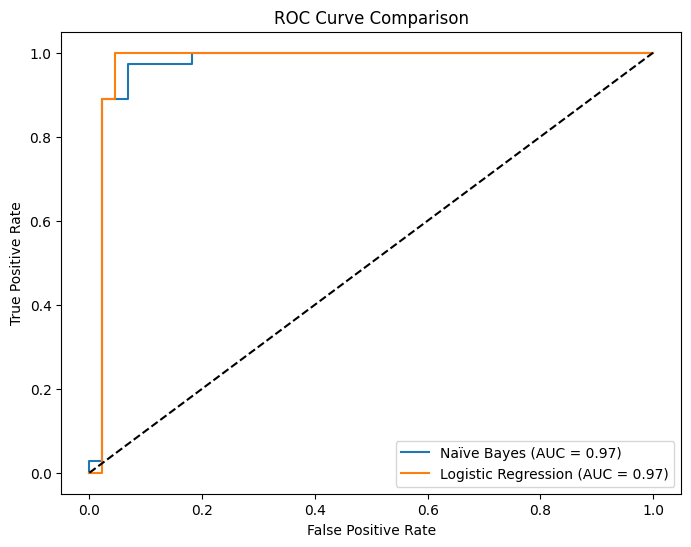

In [ ]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    # Get probability scores for the positive class (Real News)
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--') # Diagonal dashed line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# Get feature names from the vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = lr_model.coef_[0]

# Combine into a DataFrame
feature_importance = pd.DataFrame({'word': feature_names, 'coefficient': coefficients})

print("\nTop 10 Words Indicating REAL News:")
print(feature_importance.sort_values(by='coefficient', ascending=False).head(10))

print("\nTop 10 Words Indicating FAKE News:")
print(feature_importance.sort_values(by='coefficient', ascending=True).head(10))


Top 10 Words Indicating REAL News:
             word  coefficient
10916        said     2.248472
10628     reuters     1.447490
8768           on     1.111689
2475        china     0.821183
8084     minister     0.740750
13570  washington     0.701256
6375           in     0.624111
6145        house     0.598913
8193       monday     0.593342
6807          its     0.576815

Top 10 Words Indicating FAKE News:
          word  coefficient
6769        is    -1.331281
13941      you    -1.206185
12549     that    -1.059638
12596     this    -0.710919
5948       her    -0.666467
12582     they    -0.658347
6799        it    -0.655079
11615       so    -0.641346
2723       com    -0.634719
5997   hillary    -0.615065
